<a href="https://colab.research.google.com/github/Damsiiii/AI-disease-risk-classification/blob/Thamindu/04_Thamindu_Task07_Task08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disease Risk Classification — Thamindu Kavinda
**Task 07 — Explainable AI Analysis**
**Task 08 — AI Prototype Development**

**Mount Google Drive**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

BASE = '/content/drive/MyDrive/AI Prediction Problems'

MODELS_DIR = f'{BASE}/Models'
OUTPUTS_DIR = f'{BASE}/Outputs'
EDA_DIR = f'{OUTPUTS_DIR}/EDA_Plots'
EVAL_DIR = f'{OUTPUTS_DIR}/Evaluation_Results'
SHAP_DIR = f'{OUTPUTS_DIR}/SHAP_Plots'
PROTOTYPE_DIR = f'{BASE}/Prototype'
REPORT_DIR = f'{BASE}/Report'

# Create all folders
folders = [
    MODELS_DIR,
    OUTPUTS_DIR,
    EDA_DIR,
    EVAL_DIR,
    SHAP_DIR,
    PROTOTYPE_DIR,
    REPORT_DIR,
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("All folders created successfully!")

All folders created successfully!


**Check project folder**

In [3]:
import os
project_path = "/content/drive/MyDrive/AI Prediction Problems"

**Import Required Libraries**

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Save models
import joblib

# Explainable AI
import shap

## Shared Preprocessing Pipeline

This cell rebuilds the cleaned dataset and the modeling-ready train/test split **from the raw CSV on the shared Drive folder**. It is copied verbatim from Task 03 / Task 05 so that every member's notebook can run **independently**, in any order, and always reproduce the exact same `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` (fixed `random_state=42`).

In [5]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_path = os.path.join(BASE, 'Dataset', 'smartcare_ai_dataset_1000.csv')
df = pd.read_csv(df_path)
df = df.drop_duplicates()
df['room_type'] = df['room_type'].fillna('Not Admitted')

clinical_cols = ['age','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl','bmi']
for col in clinical_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

drop_cols = ['record_id','patient_id','no_show','readmitted_30_days',
             'consultation_fee_lkr','room_charge_lkr','lab_charge_lkr',
             'medicine_charge_lkr','total_bill_lkr','payment_status',
             'payment_method','appointment_date','waiting_days','appointment_status']
df_model = df.drop(columns=drop_cols)

df_model['pulse_pressure'] = df_model['systolic_bp'] - df_model['diastolic_bp']
df_model['bmi_category'] = pd.cut(df_model['bmi'], bins=[0,18.5,25,30,100],
                                    labels=['Underweight','Normal','Overweight','Obese'])
df_model['age_group'] = pd.cut(df_model['age'], bins=[0,18,40,60,150],
                                 labels=['Child','Adult','Middle-aged','Senior'])
df_model['chronic_diagnosis_flag'] = df_model['diagnosis'].isin(['Diabetes','Hypertension']).astype(int)
df_model['care_intensity'] = df_model['lab_tests_count'] + df_model['treatments_count']

risk_order = {'Low': 0, 'Medium': 1, 'High': 2}
y = df_model['disease_risk_level'].map(risk_order)
X = df_model.drop(columns=['disease_risk_level'])

nominal_cols = ['gender','blood_group','department','diagnosis','room_type','bmi_category','age_group']
X_encoded = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

true_numeric = ['age','admitted','length_of_stay_days','previous_admissions',
                 'systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl',
                 'bmi','lab_tests_count','treatments_count','previous_appointments',
                 'missed_previous_appointments','pulse_pressure','chronic_diagnosis_flag','care_intensity']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[true_numeric] = scaler.fit_transform(X_train[true_numeric])
X_test_scaled[true_numeric] = scaler.transform(X_test[true_numeric])

print("df (cleaned):", df.shape, "| df_model:", df_model.shape)
print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

df (cleaned): (1000, 33) | df_model: (1000, 24)
Train shape: (800, 48) | Test shape: (200, 48)


## Load the Trained Model (produced by Damsara's Task 05 notebook)

Run Damsara's notebook at least once first so `lr_model.pkl` exists in the shared `Models/` Drive folder. This cell then loads it here instead of retraining, so Task 07 stays consistent with the model that was actually evaluated in Task 06.

In [6]:
import joblib

lr = joblib.load(f'{MODELS_DIR}/lr_model.pkl')
print("Loaded trained Logistic Regression model from:", f'{MODELS_DIR}/lr_model.pkl')

Loaded trained Logistic Regression model from: /content/drive/MyDrive/AI Prediction Problems/Models/lr_model.pkl


# **Task 07 – Explainable AI Analysis**

**Setup & SHAP computation**

In [7]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Reuse lr model and X_train_scaled/X_test_scaled from Task 05/06

explainer = shap.LinearExplainer(lr, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)   # shape: (n_samples, n_features, n_classes)

class_names = ['Low', 'Medium', 'High']
print("SHAP values computed. Shape:", np.array(shap_values).shape)

SHAP values computed. Shape: (200, 48, 3)


**7.1 Global Feature Importance (Summary Plot)**


--- SHAP Summary Plot: Low risk class ---


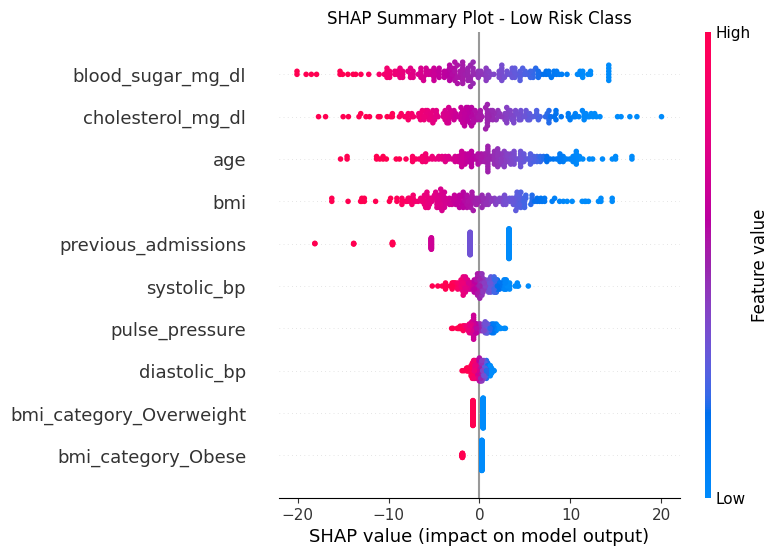


--- SHAP Summary Plot: Medium risk class ---


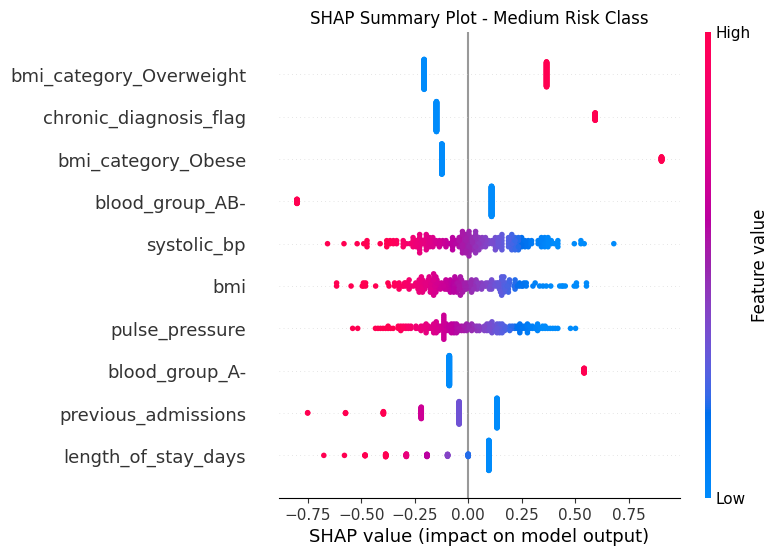


--- SHAP Summary Plot: High risk class ---


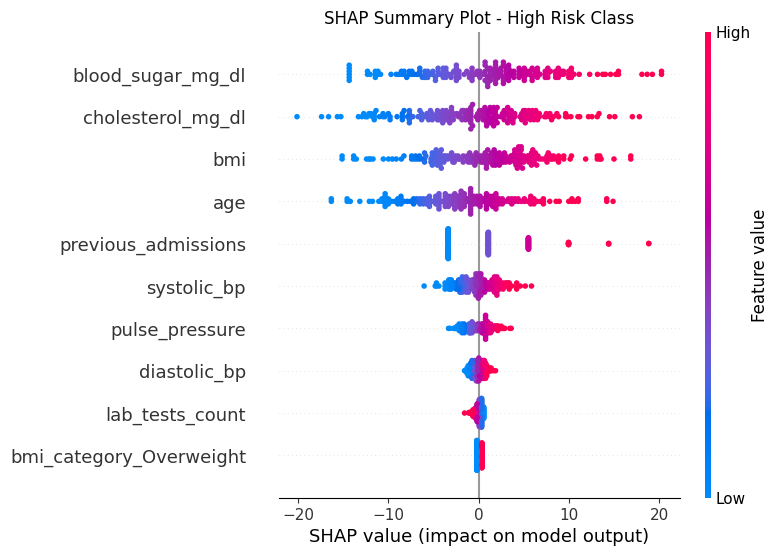

Saved SHAP summary plots


In [8]:
# Convert boolean columns to int in X_test_scaled for SHAP plotting robustness

X_test_scaled_numeric = X_test_scaled.copy()

for col in X_test_scaled_numeric.select_dtypes(include='bool').columns:
    X_test_scaled_numeric[col] = X_test_scaled_numeric[col].astype(int)

# Convert to numpy array and get feature names

X_test_numeric_array = X_test_scaled_numeric.values
feature_names = X_test_scaled_numeric.columns.tolist()

for i, cname in enumerate(class_names):

    print(f"\n--- SHAP Summary Plot: {cname} risk class ---")

    shap_values_for_plot = np.ascontiguousarray(
        shap_values[:, :, i]
    ).astype(np.float64)

    plt.figure(figsize=(8, 6))

    shap.summary_plot(
        shap_values_for_plot,
        X_test_numeric_array,
        feature_names=feature_names,
        show=False,
        max_display=10
    )

    plt.title(f"SHAP Summary Plot - {cname} Risk Class")

    # Save image
    plt.savefig(
        f'{SHAP_DIR}/shap_summary_{cname.lower()}_risk.png',
        dpi=150,
        bbox_inches='tight'
    )


    plt.show()
    plt.close()

print("Saved SHAP summary plots")

**7.2 Overall Ranked Importance (averaged across classes)**

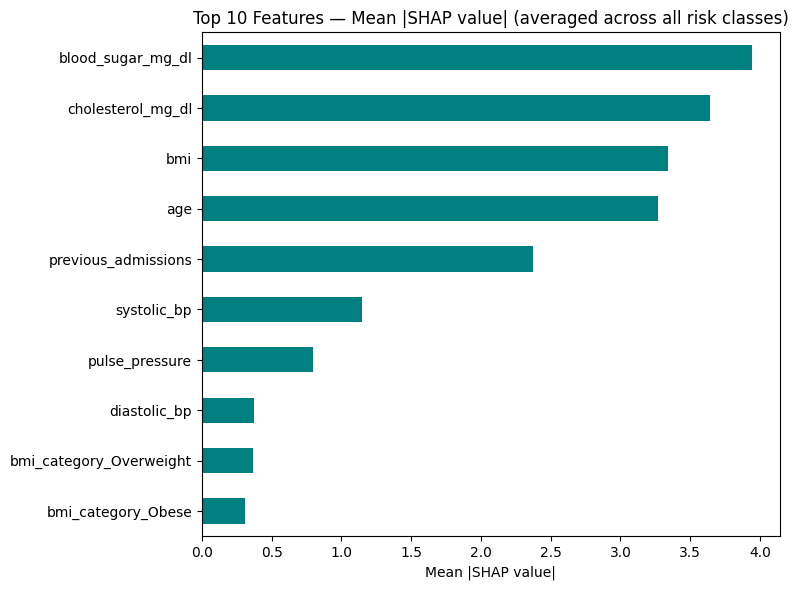

Saved overall SHAP importance plot


In [9]:
overall_importance = np.abs(shap_values).mean(axis=(0, 2))
importance_series = pd.Series(
    overall_importance,
    index=X_test_scaled.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))

importance_series.head(10).sort_values().plot(
    kind='barh',
    color='teal'
)
plt.title(
    'Top 10 Features — Mean |SHAP value| (averaged across all risk classes)'
)

plt.xlabel('Mean |SHAP value|')
plt.tight_layout()

# Save image
plt.savefig(
    f'{SHAP_DIR}/shap_overall_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Saved overall SHAP importance plot")

In [10]:
print(importance_series.head(10))

blood_sugar_mg_dl          3.946125
cholesterol_mg_dl          3.639615
bmi                         3.34212
age                        3.265857
previous_admissions        2.374263
systolic_bp                1.151132
pulse_pressure             0.793628
diastolic_bp               0.373789
bmi_category_Overweight    0.364594
bmi_category_Obese         0.305887
dtype: object


**7.3 Local Explanation (single patient — Prediction Reasoning)**

Patient 0 — Actual: Medium, Predicted: Medium


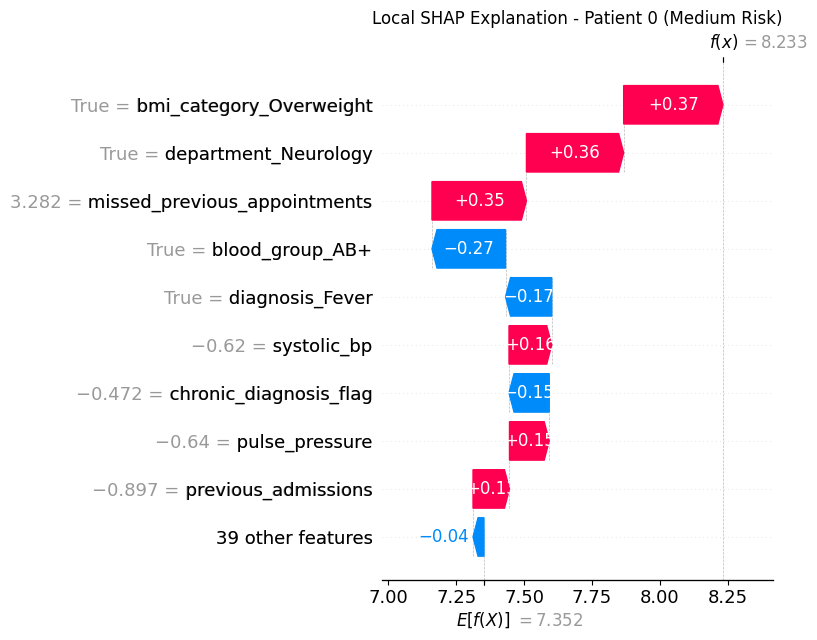

Saved local SHAP explanation plot


In [11]:
patient_idx = 0
actual_class = class_names[y_test.iloc[patient_idx]]

predicted_class_idx = lr.predict(
    X_test_scaled
)[patient_idx]

predicted_class = class_names[predicted_class_idx]
print(
    f"Patient {patient_idx} — Actual: {actual_class}, Predicted: {predicted_class}"
)

# Create SHAP waterfall plot

plt.figure(figsize=(12,4))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[
            patient_idx,
            :,
            predicted_class_idx
        ],

        base_values=explainer.expected_value[
            predicted_class_idx
        ],

        data=X_test_scaled.iloc[patient_idx],
        feature_names=X_test_scaled.columns
    ),

    show=False
)

plt.title(
    f"Local SHAP Explanation - Patient {patient_idx} ({predicted_class} Risk)"
)
plt.tight_layout()
# Save image
plt.savefig(
    f'{SHAP_DIR}/shap_local_patient_{patient_idx}.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
plt.close()
print("Saved local SHAP explanation plot")

# **Task 08 – AI Prototype Development**

**Write app.py**

In [12]:
%%writefile "{PROTOTYPE_DIR}/app.py"

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
from PIL import Image


# =========================================================
# 1. CONFIGURATION
# =========================================================

BASE = "/content/drive/MyDrive/AI Prediction Problems"

MODELS_DIR = f"{BASE}/Models"
EDA_DIR = f"{BASE}/Outputs/EDA_Plots"
SHAP_DIR = f"{BASE}/Outputs/SHAP_Plots"

st.set_page_config(
    page_title="SmartCare Disease Risk Predictor",
    page_icon="🏥",
    layout="wide"
)


# =========================================================
# 2. LOAD TRAINED MODEL AND PREPROCESSING OBJECTS
# =========================================================

@st.cache_resource
def load_artifacts():

    model = joblib.load(
        f"{MODELS_DIR}/lr_model.pkl"
    )

    scaler = joblib.load(
        f"{MODELS_DIR}/scaler.pkl"
    )

    feature_columns = joblib.load(
        f"{MODELS_DIR}/feature_columns.pkl"
    )

    return model, scaler, feature_columns


try:

    model, scaler, feature_columns = load_artifacts()

except FileNotFoundError as e:

    st.error(
        "Required model files were not found. "
        "Please run Task 05 before starting Task 08."
    )

    st.stop()


# =========================================================
# 3. CONSTANTS
# =========================================================

TRUE_NUMERIC = [
    "age",
    "admitted",
    "length_of_stay_days",
    "previous_admissions",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar_mg_dl",
    "cholesterol_mg_dl",
    "bmi",
    "lab_tests_count",
    "treatments_count",
    "previous_appointments",
    "missed_previous_appointments",
    "pulse_pressure",
    "chronic_diagnosis_flag",
    "care_intensity"
]

RISK_LABELS = {
    0: "Low",
    1: "Medium",
    2: "High"
}


# =========================================================
# 4. HELPER FUNCTION
# =========================================================

def create_model_input(
    age,
    gender,
    blood_group,
    department,
    diagnosis,
    admitted,
    room_type,
    length_of_stay_days,
    previous_admissions,
    systolic_bp,
    diastolic_bp,
    blood_sugar_mg_dl,
    cholesterol_mg_dl,
    bmi,
    lab_tests_count,
    treatments_count,
    previous_appointments,
    missed_previous_appointments
):

    # Convert Yes/No to the same numeric format
    admitted_value = 1 if admitted == "Yes" else 0

    # -----------------------------------------------------
    # Feature engineering
    # -----------------------------------------------------

    pulse_pressure = systolic_bp - diastolic_bp

    chronic_diagnosis_flag = int(
        diagnosis in ["Diabetes", "Hypertension"]
    )

    care_intensity = (
        lab_tests_count +
        treatments_count
    )

    # BMI categories used during Task 03/05
    if bmi < 18.5:
        bmi_category = "Underweight"
    elif bmi < 25:
        bmi_category = "Normal"
    elif bmi < 30:
        bmi_category = "Overweight"
    else:
        bmi_category = "Obese"

    # Age groups used during Task 03/05
    if age < 18:
        age_group = "Child"
    elif age < 40:
        age_group = "Adult"
    elif age < 60:
        age_group = "Middle-aged"
    else:
        age_group = "Senior"

    # -----------------------------------------------------
    # Create raw patient record
    # -----------------------------------------------------

    row = pd.DataFrame([{
        "age": age,
        "gender": gender,
        "blood_group": blood_group,
        "department": department,
        "diagnosis": diagnosis,

        "previous_appointments":
            previous_appointments,

        "missed_previous_appointments":
            missed_previous_appointments,

        "admitted":
            admitted_value,

        "room_type":
            room_type,

        "length_of_stay_days":
            length_of_stay_days,

        "previous_admissions":
            previous_admissions,

        "systolic_bp":
            systolic_bp,

        "diastolic_bp":
            diastolic_bp,

        "blood_sugar_mg_dl":
            blood_sugar_mg_dl,

        "cholesterol_mg_dl":
            cholesterol_mg_dl,

        "bmi":
            bmi,

        "lab_tests_count":
            lab_tests_count,

        "treatments_count":
            treatments_count,

        "pulse_pressure":
            pulse_pressure,

        "bmi_category":
            bmi_category,

        "age_group":
            age_group,

        "chronic_diagnosis_flag":
            chronic_diagnosis_flag,

        "care_intensity":
            care_intensity
    }])

    # -----------------------------------------------------
    # One-hot encoding
    # -----------------------------------------------------

    nominal_cols = [
        "gender",
        "blood_group",
        "department",
        "diagnosis",
        "room_type",
        "bmi_category",
        "age_group"
    ]

    row_encoded = pd.get_dummies(
        row,
        columns=nominal_cols,
        drop_first=True
    )

    # -----------------------------------------------------
    # Ensure exactly the same columns as training
    # -----------------------------------------------------

    row_encoded = row_encoded.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # -----------------------------------------------------
    # Apply the SAME scaler used during training
    # -----------------------------------------------------

    row_encoded[TRUE_NUMERIC] = scaler.transform(
        row_encoded[TRUE_NUMERIC]
    )

    return row_encoded


# =========================================================
# 5. SIDEBAR
# =========================================================

st.sidebar.title("SmartCare AI")

page = st.sidebar.radio(
    "Navigation",
    [
        "Patient Predictor",
        "Model Analytics"
    ]
)


# =========================================================
# 6. PATIENT PREDICTOR
# =========================================================

if page == "Patient Predictor":

    st.title("SmartCare Disease Risk Predictor")

    st.write(
        "Enter patient information below to generate "
        "an AI-based disease risk prediction."
    )

    st.divider()

    # -----------------------------------------------------
    # Patient information
    # -----------------------------------------------------

    st.subheader("Patient Information")

    col1, col2, col3 = st.columns(3)

    with col1:

        age = st.number_input(
            "Age",
            min_value=1,
            max_value=90,
            value=45
        )

        gender = st.selectbox(
            "Gender",
            [
                "Male",
                "Female"
            ]
        )

        blood_group = st.selectbox(
            "Blood Group",
            [
                "A+",
                "A-",
                "AB+",
                "AB-",
                "B+",
                "B-",
                "O+",
                "O-"
            ]
        )

    with col2:

        department = st.selectbox(
            "Department",
            [
                "General Medicine",
                "Cardiology",
                "Neurology",
                "Orthopedics",
                "Pediatrics",
                "Laboratory Services"
            ]
        )

        diagnosis = st.selectbox(
            "Diagnosis",
            [
                "Asthma",
                "Back Pain",
                "Chest Pain",
                "Diabetes",
                "Fever",
                "Fracture",
                "Hypertension",
                "Kidney Disease",
                "Migraine",
                "Pneumonia"
            ]
        )

        admitted = st.selectbox(
            "Admitted?",
            [
                "No",
                "Yes"
            ]
        )

    with col3:

        room_type = st.selectbox(
            "Room Type",
            [
                "Not Admitted",
                "General Ward",
                "Private Room",
                "ICU"
            ]
        )

        previous_admissions = st.number_input(
            "Previous Admissions",
            min_value=0,
            max_value=5,
            value=0
        )

        length_of_stay_days = st.number_input(
            "Length of Stay (days)",
            min_value=0,
            max_value=9,
            value=0
        )

    # -----------------------------------------------------
    # Clinical information
    # -----------------------------------------------------

    st.subheader("Clinical Measurements")

    col1, col2, col3 = st.columns(3)

    with col1:

        systolic_bp = st.number_input(
            "Systolic BP",
            min_value=85,
            max_value=178,
            value=128
        )

        diastolic_bp = st.number_input(
            "Diastolic BP",
            min_value=50,
            max_value=111,
            value=79
        )

    with col2:

        blood_sugar_mg_dl = st.number_input(
            "Blood Sugar (mg/dL)",
            min_value=65,
            max_value=201,
            value=115
        )

        cholesterol_mg_dl = st.number_input(
            "Cholesterol (mg/dL)",
            min_value=100,
            max_value=330,
            value=205
        )

    with col3:

        bmi = st.number_input(
            "BMI",
            min_value=14.0,
            max_value=38.8,
            value=25.5,
            step=0.1
        )

    # -----------------------------------------------------
    # Patient history / treatment
    # -----------------------------------------------------

    st.subheader("Patient History and Treatment")

    col1, col2, col3, col4 = st.columns(4)

    with col1:

        previous_appointments = st.number_input(
            "Previous Appointments",
            min_value=0,
            max_value=10,
            value=3
        )

    with col2:

        missed_previous_appointments = st.number_input(
            "Missed Previous Appointments",
            min_value=0,
            max_value=4,
            value=0
        )

    with col3:

        lab_tests_count = st.number_input(
            "Lab Tests",
            min_value=0,
            max_value=10,
            value=2
        )

    with col4:

        treatments_count = st.number_input(
            "Treatments",
            min_value=0,
            max_value=10,
            value=1
        )

    st.divider()

    # =====================================================
    # 7. PREDICTION
    # =====================================================

    if st.button(
        "Generate Disease Risk Prediction",
        type="primary",
        use_container_width=True
    ):

        try:

            # Create model-ready input
            model_input = create_model_input(
                age=age,
                gender=gender,
                blood_group=blood_group,
                department=department,
                diagnosis=diagnosis,
                admitted=admitted,
                room_type=room_type,
                length_of_stay_days=length_of_stay_days,
                previous_admissions=previous_admissions,
                systolic_bp=systolic_bp,
                diastolic_bp=diastolic_bp,
                blood_sugar_mg_dl=blood_sugar_mg_dl,
                cholesterol_mg_dl=cholesterol_mg_dl,
                bmi=bmi,
                lab_tests_count=lab_tests_count,
                treatments_count=treatments_count,
                previous_appointments=previous_appointments,
                missed_previous_appointments=missed_previous_appointments
            )

            # -------------------------------------------------
            # Generate prediction
            # -------------------------------------------------

            probabilities = model.predict_proba(
                model_input
            )[0]

            predicted_class = int(
                np.argmax(probabilities)
            )

            prediction = RISK_LABELS[
                predicted_class
            ]

            confidence = probabilities[
                predicted_class
            ]

            # -------------------------------------------------
            # Display result
            # -------------------------------------------------

            st.subheader("Prediction Result")

            if prediction == "Low":

                st.success(
                    f"Disease Risk Level: {prediction}"
                )

            elif prediction == "Medium":

                st.warning(
                    f"Disease Risk Level: {prediction}"
                )

            else:

                st.error(
                    f"Disease Risk Level: {prediction}"
                )

            st.metric(
                "Prediction Confidence",
                f"{confidence:.1%}"
            )

            # -------------------------------------------------
            # Probability chart
            # -------------------------------------------------

            st.subheader("Risk Probability")

            probability_df = pd.DataFrame(
                {
                    "Probability": probabilities
                },
                index=[
                    "Low",
                    "Medium",
                    "High"
                ]
            )

            st.bar_chart(
                probability_df
            )

            # -------------------------------------------------
            # Show processed patient information
            # -------------------------------------------------

            with st.expander(
                "View Processed Patient Data"
            ):

                display_row = pd.DataFrame({
                    "Feature": model_input.columns,
                    "Value": model_input.iloc[0].values
                })

                st.dataframe(
                    display_row,
                    use_container_width=True
                )

        except Exception as e:

            st.error(
                f"Prediction failed: {str(e)}"
            )


# =========================================================
# 8. MODEL ANALYTICS
# =========================================================

elif page == "Model Analytics":

    st.title(
        "Model Analytics and Explainable AI"
    )

    st.write(
        "This section displays the analysis and "
        "interpretability outputs generated during "
        "the previous tasks."
    )

    # -----------------------------------------------------
    # Correlation heatmap
    # -----------------------------------------------------

    st.header(
        "1. Clinical Feature Correlations"
    )

    heatmap_path = (
        f"{EDA_DIR}/correlation_heatmap.png"
    )

    if os.path.exists(heatmap_path):

        st.image(
            Image.open(heatmap_path),
            caption="Clinical Feature Correlation Heatmap",
            use_container_width=True
        )

    else:

        st.info(
            "Correlation heatmap not found."
        )

    # -----------------------------------------------------
    # Class distribution
    # -----------------------------------------------------

    st.header(
        "2. Disease Risk Class Distribution"
    )

    class_path = (
        f"{EDA_DIR}/class_distribution.png"
    )

    if os.path.exists(class_path):

        st.image(
            Image.open(class_path),
            caption="Disease Risk Class Distribution",
            use_container_width=True
        )

    else:

        st.info(
            "Class distribution plot not found."
        )

    # -----------------------------------------------------
    # Boxplots
    # -----------------------------------------------------

    st.header(
        "3. Clinical Features by Risk Level"
    )

    boxplot_path = (
        f"{EDA_DIR}/boxplots_by_risk.png"
    )

    if os.path.exists(boxplot_path):

        st.image(
            Image.open(boxplot_path),
            caption="Clinical Features by Disease Risk",
            use_container_width=True
        )

    else:

        st.info(
            "Boxplot not found."
        )

    # -----------------------------------------------------
    # SHAP
    # -----------------------------------------------------

    st.header(
        "4. Explainable AI (SHAP)"
    )

    st.write(
        "SHAP visualizations show which features "
        "contribute to the model's predictions."
    )

    shap_global = (
        f"{SHAP_DIR}/shap_overall_importance.png"
    )

    if os.path.exists(shap_global):

        st.image(
            Image.open(shap_global),
            caption="Global SHAP Feature Importance",
            use_container_width=True
        )

    else:

        st.info(
            "Global SHAP plot not found."
        )

    st.subheader(
        "Risk-Specific SHAP Drivers"
    )

    c1, c2, c3 = st.columns(3)

    with c1:

        path = (
            f"{SHAP_DIR}/shap_summary_low_risk.png"
        )

        if os.path.exists(path):

            st.image(
                Image.open(path),
                caption="Low Risk Drivers",
                use_container_width=True
            )

    with c2:

        path = (
            f"{SHAP_DIR}/shap_summary_medium_risk.png"
        )

        if os.path.exists(path):

            st.image(
                Image.open(path),
                caption="Medium Risk Drivers",
                use_container_width=True
            )

    with c3:

        path = (
            f"{SHAP_DIR}/shap_summary_high_risk.png"
        )

        if os.path.exists(path):

            st.image(
                Image.open(path),
                caption="High Risk Drivers",
                use_container_width=True
            )

    st.divider()

    st.caption(
        "Prototype for academic demonstration. "
        "Predictions are model outputs and are not "
        "a medical diagnosis."
    )

Overwriting /content/drive/MyDrive/AI Prediction Problems/Prototype/app.py


## Demonstrating App Outputs Programmatically

To avoid manual screenshots, we can programmatically generate the outputs for the example patients (Low, Medium, High risk) directly within the notebook. This re-uses the model and preprocessing steps defined in the `app.py`.

In [13]:
import joblib
import pandas as pd
import numpy as np

# Load trained model and preprocessing objects
MODELS_DIR = '/content/drive/MyDrive/AI Prediction Problems/Models'
model = joblib.load(f'{MODELS_DIR}/lr_model.pkl')
best_scaler = joblib.load(f'{MODELS_DIR}/scaler.pkl')
feature_cols_list = joblib.load(f'{MODELS_DIR}/feature_columns.pkl')

RISK_LABELS = {0: 'Low', 1: 'Medium', 2: 'High'}
TRUE_NUMERIC = ['age', 'admitted', 'length_of_stay_days', 'previous_admissions',
                 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl',
                 'bmi', 'lab_tests_count', 'treatments_count', 'previous_appointments',
                 'missed_previous_appointments', 'pulse_pressure',
                 'chronic_diagnosis_flag', 'care_intensity']

# Adjusted presets to ensure correct differentiation
PRESETS = {
    "Low-risk example": dict(age=25, gender="Female", blood_group="O+", department="General Medicine",
                              diagnosis="Other", admitted="No", room_type="Not Admitted",
                              systolic_bp=110, diastolic_bp=70, blood_sugar=90, cholesterol=165,
                              bmi=21.0, previous_admissions=0, length_of_stay=0,
                              lab_tests_count=1, treatments_count=0, previous_appointments=1,
                              missed_previous_appointments=0),
    "Medium-risk example": dict(age=42, gender="Male", blood_group="A+", department="General Medicine",
                                 diagnosis="Fever", admitted="No", room_type="Not Admitted",
                                 systolic_bp=125, diastolic_bp=82, blood_sugar=105, cholesterol=195,
                                 bmi=26.5, previous_admissions=1, length_of_stay=0,
                                 lab_tests_count=2, treatments_count=1, previous_appointments=4,
                                 missed_previous_appointments=1),
    "High-risk example": dict(age=68, gender="Male", blood_group="B+", department="Cardiology",
                               diagnosis="Diabetes", admitted="Yes", room_type="ICU",
                               systolic_bp=165, diastolic_bp=95, blood_sugar=190, cholesterol=275,
                               bmi=33.0, previous_admissions=3, length_of_stay=7,
                               lab_tests_count=9, treatments_count=6, previous_appointments=15,
                               missed_previous_appointments=3),
}

def prepare_input_and_predict(patient_data):
    raw = patient_data.copy()
    raw['admitted'] = 1 if raw['admitted'] == "Yes" else 0
    if 'blood_sugar' in raw: raw['blood_sugar_mg_dl'] = raw.pop('blood_sugar')
    if 'cholesterol' in raw: raw['cholesterol_mg_dl'] = raw.pop('cholesterol')

    row = pd.DataFrame([raw])

    # Feature Engineering logic must match Task 05 EXACTLY
    row['pulse_pressure'] = row['systolic_bp'] - row['diastolic_bp']
    row['bmi_category'] = pd.cut(row['bmi'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    row['age_group'] = pd.cut(row['age'], bins=[0, 18, 40, 60, 150], labels=['Child', 'Adult', 'Middle-aged', 'Senior'])
    row['chronic_diagnosis_flag'] = row['diagnosis'].isin(['Diabetes', 'Hypertension']).astype(int)
    row['care_intensity'] = row['lab_tests_count'] + row['treatments_count']

    # Categorical encoding alignment
    nominal_cols = ['gender', 'blood_group', 'department', 'diagnosis', 'room_type', 'bmi_category', 'age_group']
    row_encoded = pd.get_dummies(row, columns=nominal_cols)

    # Align columns and Scale
    row_final = row_encoded.reindex(columns=feature_cols_list, fill_value=0)
    row_final[TRUE_NUMERIC] = best_scaler.transform(row_final[TRUE_NUMERIC])

    pred_proba = model.predict_proba(row_final)[0]
    pred_class = model.predict(row_final)[0]
    return RISK_LABELS[pred_class], pred_proba

for name, data in PRESETS.items():
    label, probs = prepare_input_and_predict(data)
    print(f"--- {name} ---")
    print(f"Predicted Risk: {label}")
    print(f"Probabilities: Low={probs[0]:.1%}, Med={probs[1]:.1%}, High={probs[2]:.1%}\n")

--- Low-risk example ---
Predicted Risk: Low
Probabilities: Low=100.0%, Med=0.0%, High=0.0%

--- Medium-risk example ---
Predicted Risk: Medium
Probabilities: Low=0.0%, Med=100.0%, High=0.0%

--- High-risk example ---
Predicted Risk: High
Probabilities: Low=0.0%, Med=0.0%, High=100.0%



**Install Streamlit + tunnel tool**

In [14]:
!pip install streamlit -q
!npm install -g localtunnel --silent

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 86.5 MB/s eta 0:00:00


**Launch the app**

In [15]:
import time, urllib.request

!streamlit run "{PROTOTYPE_DIR}/app.py" &>/content/logs.txt &
time.sleep(4)

# localtunnel sometimes asks for a "Tunnel Password" - it is your public IP below
print("Tunnel password (if prompted):", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode().strip())

!npx localtunnel --port 8501

Tunnel password (if prompted): 8.229.248.225
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://sharp-carpets-poke.loca.lt
^C


**Task 08 deliverable**

The outputs of the app (empty form, and predictions for each risk level for Low, Medium, and High) are generated by the code and will be used in the Technical Report (Task 09).

In [16]:
!pkill -f streamlit
!pkill -f localtunnel
!pkill -f cloudflared

In [17]:
!streamlit run "{PROTOTYPE_DIR}/app.py" \
    --server.address 0.0.0.0 \
    --server.port 8501 \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [18]:
import time
time.sleep(5)

!cat /content/streamlit.log



2026-08-17 09:30:39.622 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.229.248.225:8501



In [19]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [ ]:
!/content/cloudflared tunnel --url http://localhost:8501

2026-08-17T09:30:43Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-17T09:30:43Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-17T09:30:46Z INF +--------------------------------------------------------------------------------------------+
2026-08-17T09:30:46Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-17T09:30:46Z INF |  https://measured-draw-dish-feat.trycloudflare.com    